In [2]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


🔍 Training Binary CatBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

📊 Classification Report (Binary):
                precision    recall  f1-score   support

No Interaction       0.95      0.94      0.94      2211
   Interaction       0.94      0.96      0.95      2405

      accuracy                           0.95      4616
     macro avg       0.95      0.95      0.95      4616
  weighted avg       0.95      0.95      0.95      4616



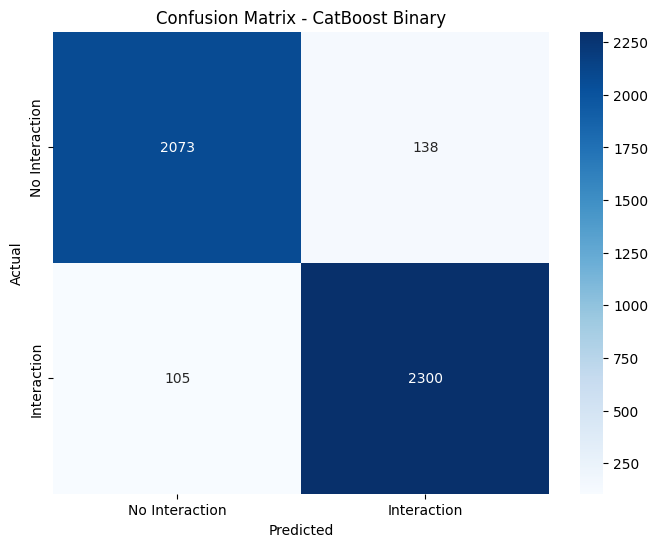

In [3]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ====================== LOAD DATA ======================
df = pd.read_csv('DDinter_with_negatives.csv')

df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

# ====================== BINARY TARGET ======================
df['Level_binary'] = df['Level'].apply(
    lambda x: 0 if str(x).strip().lower() in ['none', 'no interaction', '0'] else 1
)

# ====================== CLEAN ======================
df = df.dropna(subset=['Drug_A', 'Drug_B', 'Level_binary'])
df = df.drop_duplicates()

X = df[['Drug_A', 'Drug_B']]
y = df['Level_binary']

# Identify categorical columns (VERY IMPORTANT for CatBoost)
cat_features = [0, 1]  # column indices of Drug_A and Drug_B

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====================== MODEL ======================
model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0
)

# ====================== PARAM SEARCH ======================
param_dist = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 400, 600],
    'l2_leaf_reg': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("🔍 Training Binary CatBoost...")
random_search.fit(X_train, y_train, cat_features=cat_features)

best_model = random_search.best_estimator_

# ====================== EVALUATION ======================
y_pred = best_model.predict(X_test)

print("\n📊 Classification Report (Binary):")
print(classification_report(
    y_test, y_pred,
    target_names=['No Interaction', 'Interaction']
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Interaction', 'Interaction'],
            yticklabels=['No Interaction', 'Interaction'])
plt.title("Confusion Matrix - CatBoost Binary")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [4]:
# ====================== SAVE MODEL ======================
import joblib

joblib.dump(best_model, 'ddi_binary_cb_model.pkl')
print("\n✅ Model saved as 'ddi_binary_cb_model.pkl'")


✅ Model saved as 'ddi_binary_cb_model.pkl'


In [5]:
# ====================== ADDITIONAL METRICS ======================
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


✅ Accuracy: 0.9474 (94.74%)


In [6]:
# ====================== OVERALL METRICS (Binary - Balanced) ======================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Overall metrics for binary classification (Interaction = positive class)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary', pos_label=1)
recall    = recall_score(y_test, y_pred, average='binary', pos_label=1)
f1        = f1_score(y_test, y_pred, average='binary', pos_label=1)

print("\n" + "="*55)
print("📊 OVERALL METRICS (Binary Classification)")
print("="*55)
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*55)


📊 OVERALL METRICS (Binary Classification)
Accuracy  : 0.9474  (94.74%)
Precision : 0.9434
Recall    : 0.9563
F1-Score  : 0.9498
